# Task (c) — Distributions of hits and tracks in x, y and phi

Task (b) gave me the 10,000-event dataset (10 tracks each, 95% efficiency,
sigma = 0.001*R smearing). Task (c) asks for histograms of the hits and the
tracks in x, y and phi (the angle to the x-axis).

A quick note on what I histogram for each. For the hits, x and y are the recorded
positions and phi is atan2(y, x). For the tracks, a straight track from the
origin has no single (x, y) point as it's a ray so the natural 'x and y of a
track' are the components of its direction, cos(phi) and sin(phi). Phi is the
true track angle, one entry per track. Since I know exactly how the data was
generated, I can also overlay the expected shape on each histogram as a check
that tasks (a) and (b) behaved.

### Setup

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- simulator ----
COLUMNS = ["event_id", "track_id", "layer", "x", "y", "phi"]


def detector_radii(n_circles: int = 5, spacing: float = 2.0) -> np.ndarray:
    return spacing * np.arange(1, n_circles + 1)


def sample_track_angles(n_tracks: int,
                        rng: np.random.Generator,
                        min_sep: float = 0.0) -> np.ndarray:
    if min_sep <= 0.0:
        return rng.uniform(0.0, 2.0 * np.pi, size=n_tracks)

    phis: list[float] = []
    while len(phis) < n_tracks:
        cand = rng.uniform(0.0, 2.0 * np.pi)
        if all(_angular_gap(cand, p) >= min_sep for p in phis):
            phis.append(cand)
    return np.array(phis)


def _angular_gap(a: float, b: float) -> float:
    d = abs(a - b) % (2.0 * np.pi)
    return min(d, 2.0 * np.pi - d)


def track_hits(phi: float, radii: np.ndarray) -> np.ndarray:
    x = radii * np.cos(phi)
    y = radii * np.sin(phi)
    return np.column_stack([x, y])


def simulate_event(event_id: int,
                   n_tracks: int = 3,
                   n_circles: int = 5,
                   spacing: float = 2.0,
                   efficiency: float = 1.0,
                   smear: float = 0.0,
                   min_sep: float = 0.0,
                   rng: np.random.Generator | None = None) -> pd.DataFrame:
    if rng is None:
        rng = np.random.default_rng()

    radii = detector_radii(n_circles, spacing)
    phis = sample_track_angles(n_tracks, rng, min_sep=min_sep)

    rows = []
    for track_id, phi in enumerate(phis):
        hits = track_hits(phi, radii)                 
        keep = rng.random(n_circles) < efficiency
        layers = np.nonzero(keep)[0]
        hits = hits[keep]
        if smear > 0.0 and len(hits):
            sigma = smear * radii[keep]
            noise = rng.normal(0.0, 1.0, hits.shape) * sigma[:, None]
            hits = hits + noise

        for layer, (x, y) in zip(layers, hits):
            rows.append((event_id, track_id, layer, x, y, phi))

    return pd.DataFrame(rows, columns=COLUMNS)


def simulate_events(n_events: int, seed: int | None = None, **kwargs) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    frames = [simulate_event(i, rng=rng, **kwargs) for i in range(n_events)]
    return pd.concat(frames, ignore_index=True)


# ---- plotting ----
_COLORS = plt.cm.tab10.colors
def draw_detector(ax, radii):
    for r in radii:
        ax.add_patch(plt.Circle((0, 0), r, fill=False, color="tab:blue", lw=1.1))


def plot_event(event, ax=None, radii=None, show_rays=True, legend=True):
    if radii is None:
        radii = detector_radii(5, 2.0)
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    R = radii.max()
    draw_detector(ax, radii)

    for track_id, g in event.groupby("track_id"):
        c = _COLORS[track_id % 10]
        if show_rays:
            phi = g["phi"].iloc[0]
            ax.plot([0, R * np.cos(phi)], [0, R * np.sin(phi)],
                    color=c, lw=1, alpha=0.5)
        ax.scatter(g["x"], g["y"], color=c, s=35, zorder=3,
                   label=f"track {track_id}")

    lim = R * 1.1
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    if legend:
        ax.legend(loc="upper right", fontsize=8)
    return ax

from scipy.stats import chisquare
RADII = detector_radii(5, 2.0); SMEAR = 0.001; EFF = 0.95
os.makedirs('figures', exist_ok=True); FIGDIR = 'figures'

df = simulate_events(10000, seed=2026, n_tracks=10, efficiency=EFF, smear=SMEAR)

df['phi_hit'] = np.mod(np.arctan2(df['y'], df['x']), 2.0 * np.pi)

tracks = df.drop_duplicates(['event_id', 'track_id'])[['event_id', 'track_id', 'phi']]
print(f'{len(df):,} hits and {len(tracks):,} tracks')

475,028 hits and 100,000 tracks


## 1. Hits in x and y
Each hit sits on a circle at x = R*cos(phi) with phi uniform. Changing variables
from phi to x gives the arcsine law, f(x) = 1 / (pi * sqrt(R^2 - x^2)), which is
U-shaped and piles up near x = +/-R (there the circle runs almost vertical, so
lots of angles map to nearly the same x). My hits come from all five circles, so
I expect peaks at +/-2, +/-4, +/-6, +/-8, +/-10; y looks the same by symmetry. I
overlay the analytic curve as a check. The tiny smearing is invisible at this
scale.

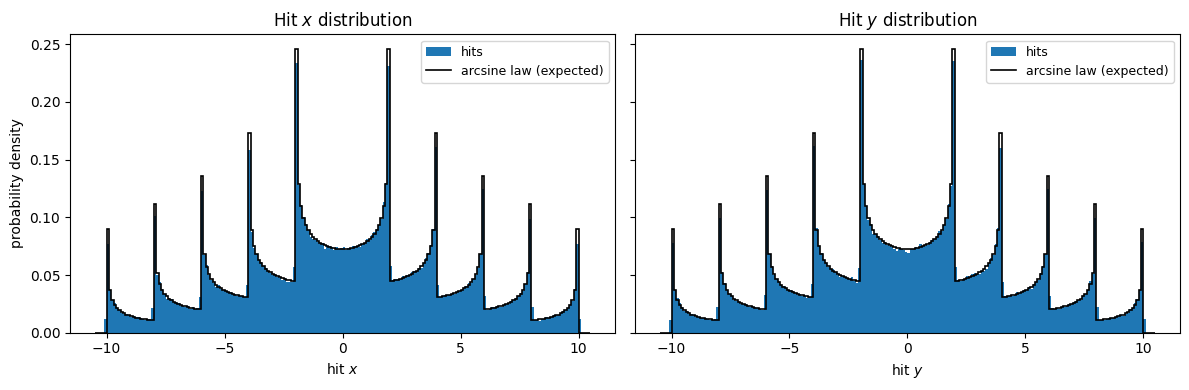

In [2]:
def arcsine_cdf(x, R):
    # CDF of x = R*cos(phi) when phi is uniform: 1/2 + arcsin(x/R)/pi.
    return 0.5 + np.arcsin(np.clip(x / R, -1.0, 1.0)) / np.pi

def mixture_bin_density(edges, radii):
    # Expected density in each bin, averaging the arcsine law over the 5 circles.
    p = np.zeros(len(edges) - 1)
    for R in radii:
        p += (arcsine_cdf(edges[1:], R) - arcsine_cdf(edges[:-1], R)) / len(radii)
    return p / np.diff(edges)

edges = np.linspace(-10.5, 10.5, 211)          # 0.1-wide bins
expected = mixture_bin_density(edges, RADII)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, coord in zip(axes, ['x', 'y']):
    ax.hist(df[coord], bins=edges, density=True, color='tab:blue', label='hits')
    ax.stairs(expected, edges, color='k', lw=1.2, label='arcsine law (expected)')
    ax.set_xlabel(f'hit ${coord}$'); ax.set_title(f'Hit ${coord}$ distribution')
    ax.legend(fontsize=9)
axes[0].set_ylabel('probability density')
fig.tight_layout(); fig.savefig(os.path.join(FIGDIR, 'c1_hit_x_y.png'), dpi=150)
plt.show()

## 2. Hits in phi
The hit angle should be uniform on [0, 2*pi), tracks go in all directions
equally and neither the efficiency nor the smearing prefers a direction. I run
a chi-squared test as a rough check. One caveat: the ~4.75 hits of a single
track share almost the same phi, so the hits aren't fully independent and the
raw chi-squared is a bit inflated. The cleaner test is on the track angles in
the next section, where each entry is independent.

hits in phi: chi2/ndf = 311.4/71  (mildly inflated by correlated hits; see Section 3 for the clean test)


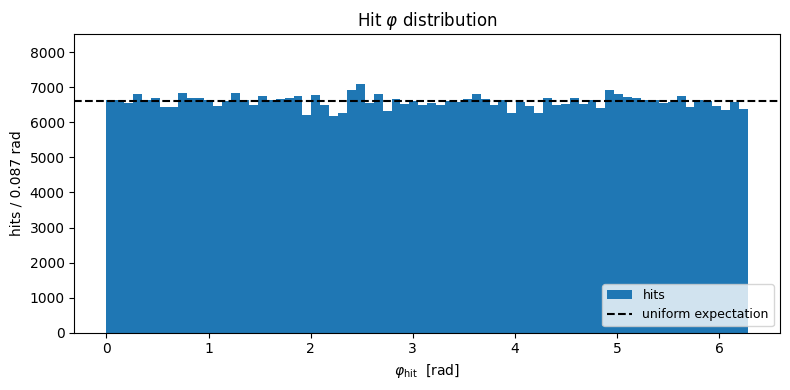

In [3]:
NB_PHI = 72                                     # 72 bins = 5 degrees each
counts, edges_phi = np.histogram(df['phi_hit'], bins=NB_PHI, range=(0.0, 2.0 * np.pi))
stat, pval = chisquare(counts)
print(f'hits in phi: chi2/ndf = {stat:.1f}/{NB_PHI - 1}  '
      f'(mildly inflated by correlated hits; see Section 3 for the clean test)')

fig, ax = plt.subplots(figsize=(8, 4))
ax.stairs(counts, edges_phi, fill=True, color='tab:blue', label='hits')
ax.axhline(len(df) / NB_PHI, color='k', ls='--', label='uniform expectation')
ax.set_xlabel(r'$\varphi_\mathrm{hit}$  [rad]')
ax.set_ylabel(f'hits / {2 * np.pi / NB_PHI:.3f} rad')
ax.set_ylim(0, counts.max() * 1.2)
ax.set_title(r'Hit $\varphi$ distribution'); ax.legend(fontsize=9, loc='lower right')
fig.tight_layout(); fig.savefig(os.path.join(FIGDIR, 'c2_hit_phi.png'), dpi=150)
plt.show()

## 3. Tracks in phi, x and y
Now one entry per track, so the entries are independent. The track angle phi is
sampled uniformly, so its histogram should be flat and the chi-squared test
should pass cleanly. The direction components cos(phi) and sin(phi) follow the
same arcsine law as section 1, but with R = 1.

tracks in phi: chi2/ndf = 65.4/71,  p = 0.666  (p > 0.05 -> consistent with uniform)


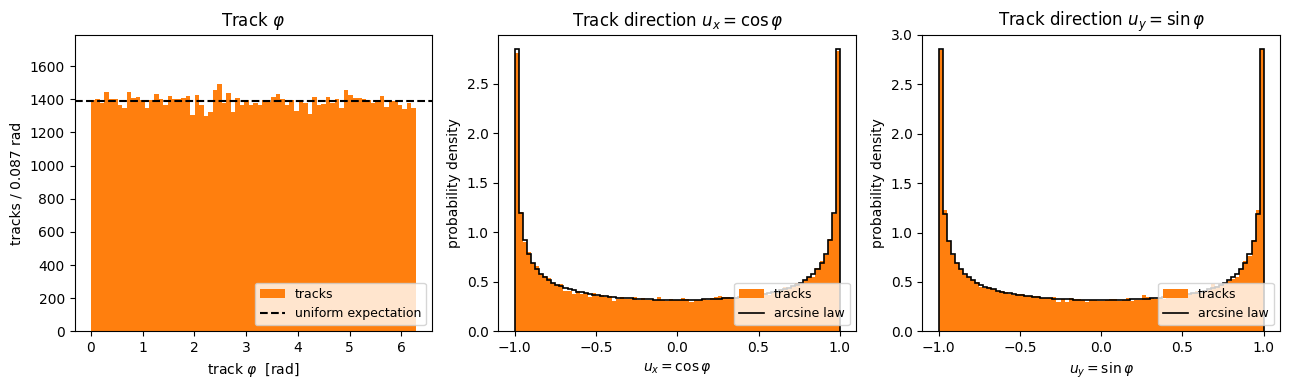

In [4]:
counts_t, edges_t = np.histogram(tracks['phi'], bins=NB_PHI, range=(0.0, 2.0 * np.pi))
stat_t, pval_t = chisquare(counts_t)
print(f'tracks in phi: chi2/ndf = {stat_t:.1f}/{NB_PHI - 1},  p = {pval_t:.3f}  '
      f'(p > 0.05 -> consistent with uniform)')

ux, uy = np.cos(tracks['phi']), np.sin(tracks['phi'])
edges_u = np.linspace(-1.0, 1.0, 81)
expected_u = mixture_bin_density(edges_u, [1.0])    # arcsine law, R = 1

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].stairs(counts_t, edges_t, fill=True, color='tab:orange', label='tracks')
axes[0].axhline(len(tracks) / NB_PHI, color='k', ls='--', label='uniform expectation')
axes[0].set_ylim(0, counts_t.max() * 1.2)
axes[0].set_xlabel(r'track $\varphi$  [rad]')
axes[0].set_ylabel(f'tracks / {2 * np.pi / NB_PHI:.3f} rad')
axes[0].set_title(r'Track $\varphi$')
for ax, u, name in [(axes[1], ux, r'$u_x=\cos\varphi$'), (axes[2], uy, r'$u_y=\sin\varphi$')]:
    ax.hist(u, bins=edges_u, density=True, color='tab:orange', label='tracks')
    ax.stairs(expected_u, edges_u, color='k', lw=1.2, label='arcsine law')
    ax.set_xlabel(name); ax.set_ylabel('probability density')
    ax.set_title(f'Track direction {name}')
for ax in axes: ax.legend(fontsize=9, loc='lower right')
fig.tight_layout(); fig.savefig(os.path.join(FIGDIR, 'c3_track_phi_xy.png'), dpi=150)
plt.show()

## Summary
To recap task (c): the hit x and y distributions are a mix of arcsine laws over
the five circles, with peaks at +/-2, +/-4, +/-6, +/-8, +/-10, and the analytic
overlay matches. The hit and track angles come out flat, as expected from
isotropic emission, and the chi-squared test on the independent track angles is
consistent with uniform. The track direction components follow the arcsine law
with R = 1.

One number worth carrying forward: the smearing sigma = 0.001*R works out to
about a 1 mrad angular resolution per hit (a tangential shift of 0.001*R tilts
the angle by 0.001*R / R = 0.001 rad, the same on every layer). 
